Name: ENJAL CHAUHAN  
Course: Advanced Big Data and Data Mining (MSCS-634-M20)    
Lab Assignment: K-Means vs K-Medoids Clustering on Wine Dataset

## Step 1: Load and Prepare Dataset

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# For K-Medoids
from sklearn_extra.cluster import KMedoids

In [2]:
# Load Wine Dataset
wine = load_wine()
X = wine.data
y = wine.target

# Convert to DataFrame for exploration
df = pd.DataFrame(X, columns=wine.feature_names)

# Display basic info
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
# Feature details
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [4]:
# Class distribution
unique, counts = np.unique(y, return_counts=True)
print("Class Distribution:")
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} samples")

Class Distribution:
Class 0: 59 samples
Class 1: 71 samples
Class 2: 48 samples


In [5]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


In [6]:
# Standardize using Z-score normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data successfully standardized.")


Data successfully standardized.


## Step 2: K-Means Clustering

In [7]:
# Apply K-Means with k = 3
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Metrics
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-Means Results:")
print("Silhouette Score:", kmeans_silhouette)
print("Adjusted Rand Index:", kmeans_ari)

K-Means Results:
Silhouette Score: 0.2848589191898987
Adjusted Rand Index: 0.8974949815093207


## Step 3: K-Medoids Clustering

In [8]:
# Apply K-Medoids with k = 3
kmedoids = KMedoids(n_clusters=3, random_state=42, method='pam')
kmedoids_labels = kmedoids.fit_predict(X_scaled)

# Metrics
kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("K-Medoids Results:")
print("Silhouette Score:", kmedoids_silhouette)
print("Adjusted Rand Index:", kmedoids_ari)


K-Medoids Results:
Silhouette Score: 0.2676220575785755
Adjusted Rand Index: 0.7411365432162113


## Step 4:Visualization

In [9]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


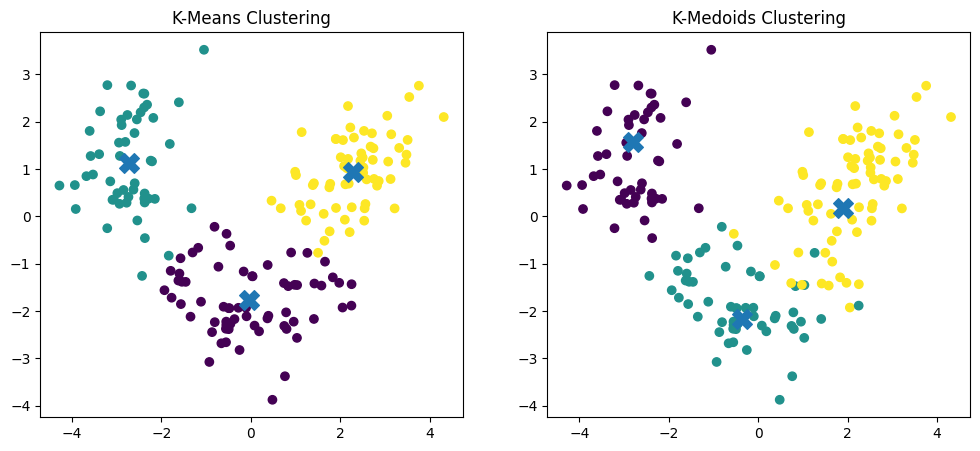

In [10]:
# Plot side-by-side clusters
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- K-Means Plot ----
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
axes[0].scatter(
    pca.transform(kmeans.cluster_centers_)[:, 0],
    pca.transform(kmeans.cluster_centers_)[:, 1],
    marker='X', s=200
)
axes[0].set_title("K-Means Clustering")

# ---- K-Medoids Plot ----
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmedoids_labels)
axes[1].scatter(
    X_pca[kmedoids.medoid_indices_, 0],
    X_pca[kmedoids.medoid_indices_, 1],
    marker='X', s=200
)
axes[1].set_title("K-Medoids Clustering")

plt.show()


## Step 5: Analysis

The clustering performance of K-Means and K-Medoids was assessed using the Silhouette Score and the Adjusted Rand Index (ARI).

K-Means obtained a Silhouette Score of **0.2849** and an ARI of **0.8975**, whereas K-Medoids yielded a Silhouette Score of **0.2676** and an ARI of **0.7411**.

The Silhouette Score quantifies the separation and cohesion of clusters. Higher values indicate that data points are closer to their assigned cluster and more distant from other clusters. In this analysis, K-Means slightly outperformed K-Medoids, indicating that K-Means produced more compact and well-separated clusters.

The Adjusted Rand Index assesses the correspondence between clustering results and true class labels. K-Means achieved a substantially higher ARI, demonstrating that its clusters aligned more closely with the actual wine classes. Although K-Medoids performed reasonably well, it exhibited lower agreement with the ground truth.

Visualizations indicate that K-Means clusters are more compact and evenly distributed, reflecting the centroid-based optimization that minimizes within-cluster variance. In contrast, K-Medoids clusters may appear less uniform because medoids are restricted to actual data points rather than mean positions.

These findings indicate that K-Means was more effective for this dataset. The Wine dataset comprises continuous numerical features and relatively well-separated classes, conditions under which K-Means typically performs optimally.

Generally, K-Means is preferable for large datasets with spherical cluster structures and minimal noise. K-Medoids demonstrates greater robustness to outliers and noise, as medoids are less affected by extreme values. Consequently, K-Medoids may be advantageous in scenarios involving noisy data, non-Euclidean distances, or when interpretability of representative data points is required.